In [1]:
# 14   - derived from 10, but here used to develop figures for the presentation. 
# Path setup
import sys, os, json, copy
cwd = os.path.abspath('.')
if os.path.basename(cwd) != 'disturbance_uncertainty':
    sys.path.insert(0, os.path.abspath('../src'))
else:
    sys.path.insert(0, os.path.abspath('./src'))

# sys.path.insert(0, os.path.abspath('../src'))
# PROJ_ROOT = os.path.abspath('..')   # notebooks/ → project root


In [2]:
# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Optical Sensor 1",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.0,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.05,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.05,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 3,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.01,
                },
            },
        },

        {
            "name": "Optical Sensor 2",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 3.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 0.1,
                "beta": 12.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.01,
            },
        },
    },
}

In [3]:
train_experiment_config = {
    "n_stacks": 10,
    # "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
    # "patch_selection_seed": 123,

    "sensor_name_for_strat": "Optical Sensor 1",
    "n_strata": 5,
    "samples_per_stratum": 50,
    #"kappa_for_logistic":2.0, # no longer needed -- using richards 1.0 is strict logistic, higher is steeper. 
    #"sampling_seed": 42,
}

In [4]:
# set up the interpreters

# new to 06 -- the interpreter stuff
from interpreter_agent import InterpreterAgent, InterpreterGroup

model_building_interp_cfg = {
    "interpreter_id": "interpreterBuildingModel",
    "consistency_std_pct": 0.00,
    "bias_std_pct": 0.0,
    "confidence_std": 0,
    #"seed": 101,
}
model_interp1 = InterpreterAgent(**model_building_interp_cfg)

validation_interp1_cfg = {
    "interpreter_id": "validation_interp1",
    "consistency_std_pct": 0.0,
    "bias_std_pct": 0.0,
    "confidence_std": 0.0,
    #"seed": 101,
}
val_interp1 = InterpreterAgent(**validation_interp1_cfg)


# usage later:  
# train_collection.buildModel(
#     sensor_names=None,
#     n_strata=5,
#     samples_per_stratum=200,
#     sampling_seed=123,
#     interpreter_agent=expert_1,
# )

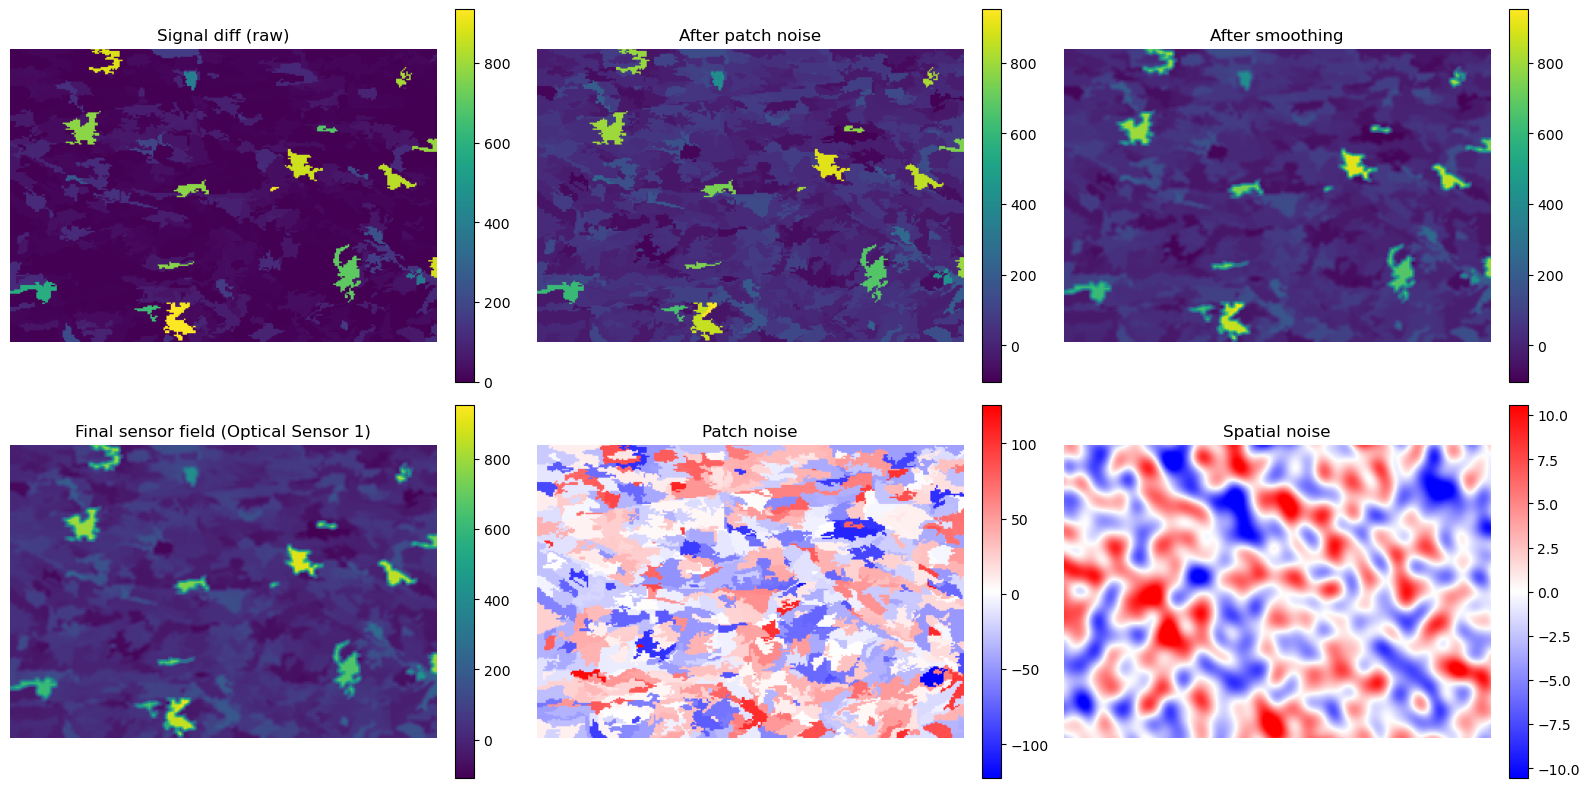

{'Optical Sensor 1': <sensor_field.SensorField object at 0x196c6f150>, 'Optical Sensor 2': <sensor_field.SensorField object at 0x196ca8d10>}


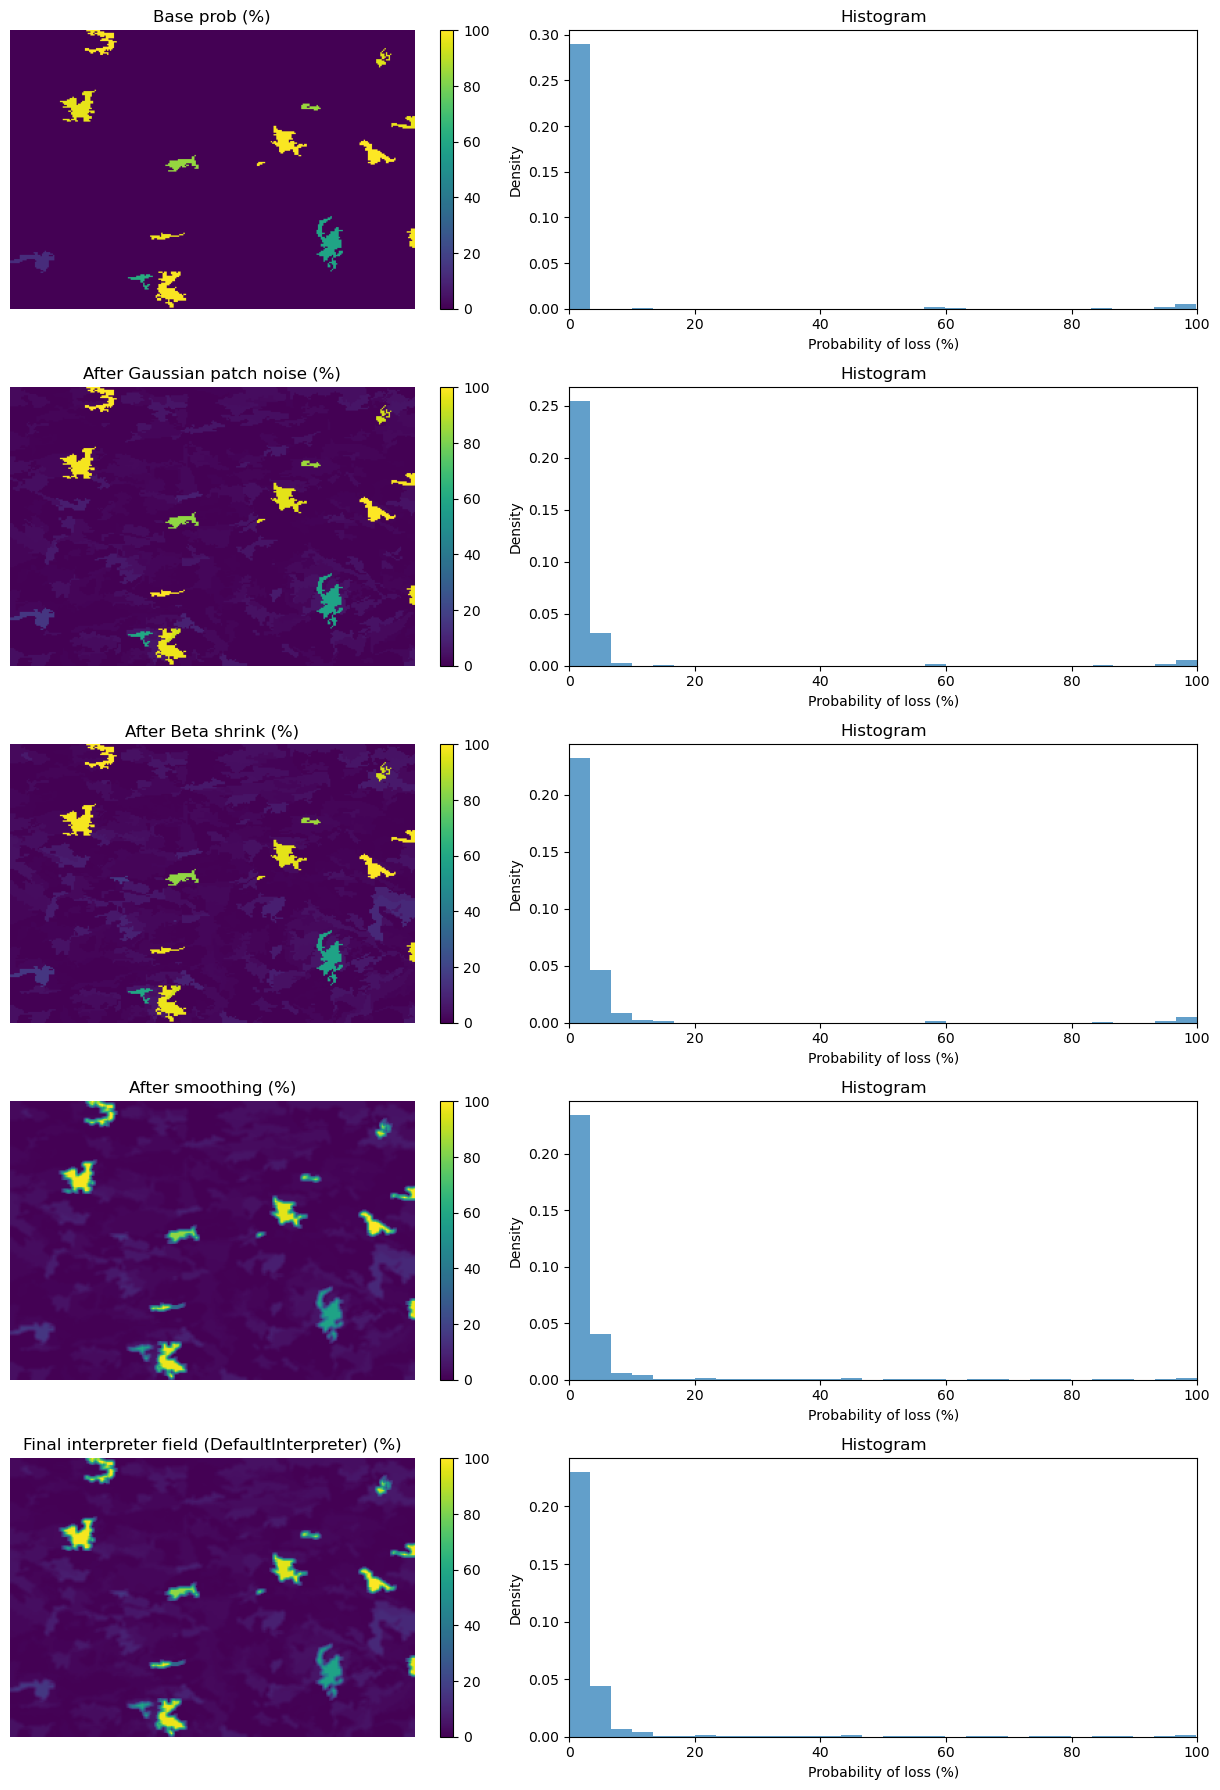

In [5]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection

from disturbance_helper_functions import flatten_config, generate_run_id, _append_to_master_log, export_with_metadata

train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=train_experiment_config,
)

# Do some diagnostic plotting for one of the landscapes 

this = train_collection.stacks[0]
this.sensor_fields['Optical Sensor 1'].plot_pipeline()

# some diagnostic plotting for the interpreter fields

print(this.sensor_fields)
print(this.interpreter_field)

this.interpreter_field.plot_pipeline()
# this.sensor_fields['Landsat_OLI'].plot_pipeline()



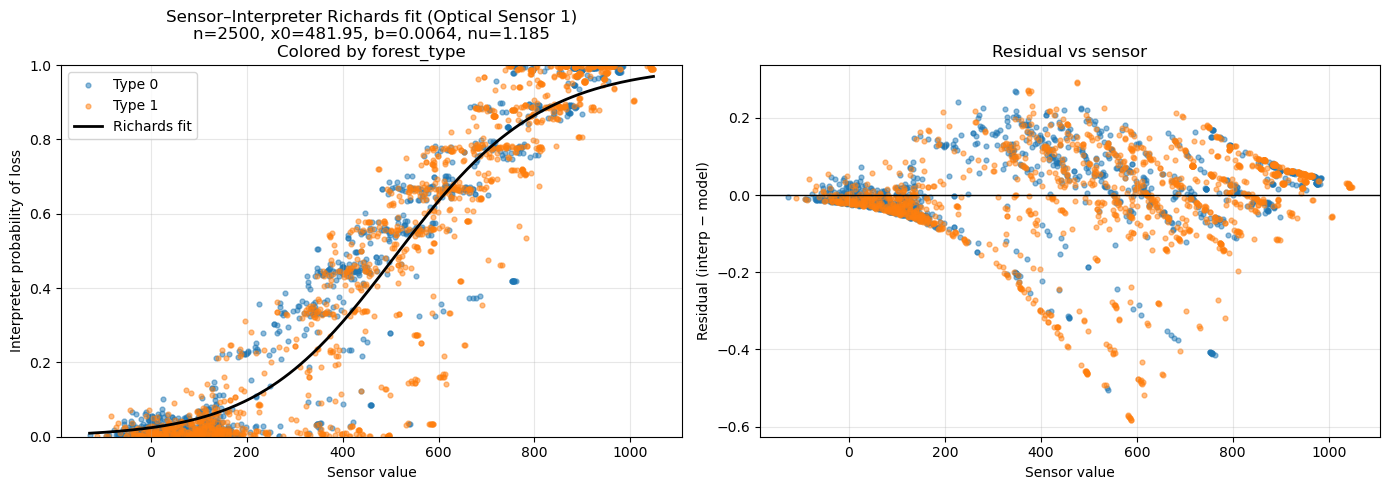

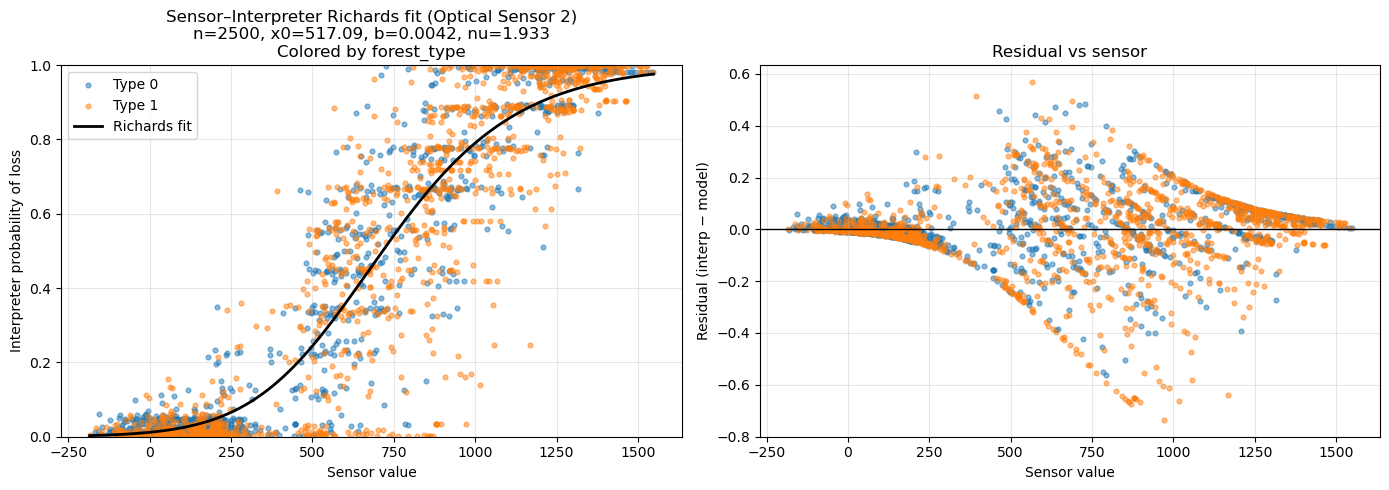

In [6]:

#  Build the continous model

trained_models = train_collection.buildModel(
                    sensor_names=None,
                    n_strata=5,
                    samples_per_stratum=50,
                    sampling_seed=123,
                    interpreter_agent=model_interp1,
                            )   #continuous logistic probability


In [7]:
# continuous model:  Validation prep

# next build a validation dataset from a different set of landscapes
#  to do this, we need to make sure that the landscapes are different.  

used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_experiment_config = {
    "n_stacks": 1,   # or however many you want for this second set
 #   "disturbance_seed_base": 20_000,
  #  "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
   # "patch_selection_seed": 456,  # different seed from training if you want

    "sensor_name_for_strat": "Optical Sensor 1",
    "n_strata": 5,
    "samples_per_stratum": 200,
#    "sampling_seed": 99,
}

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=val_experiment_config,
    exclude_tif_paths=used_tifs,
)



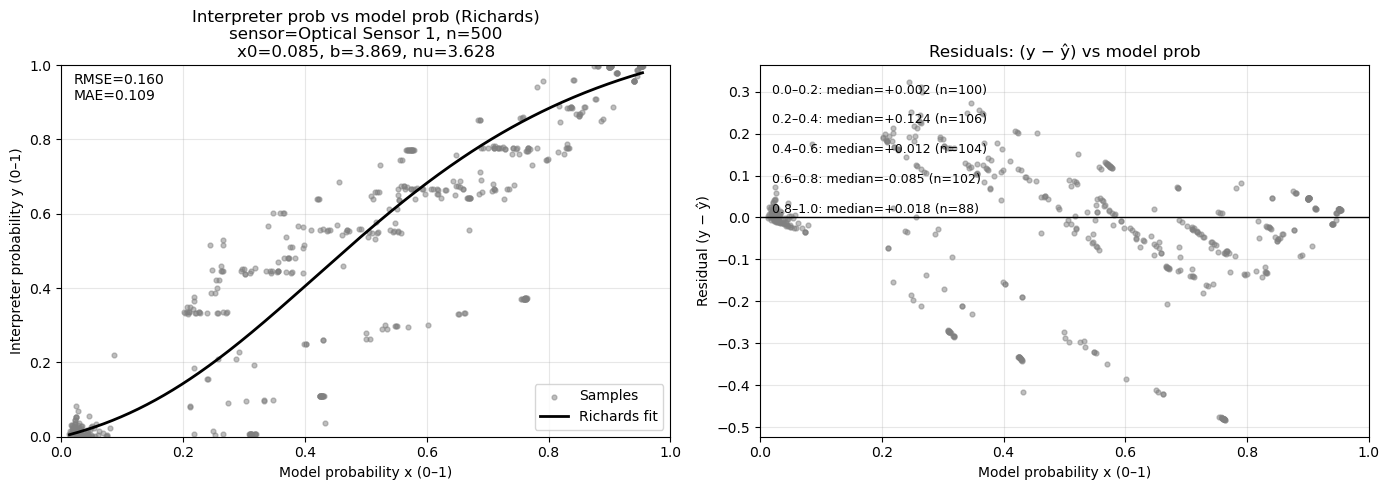

Sample size: 500
Fitted interpreter-probability model for sensor 'Optical Sensor 1': x0=0.085, b=3.869, nu=3.628


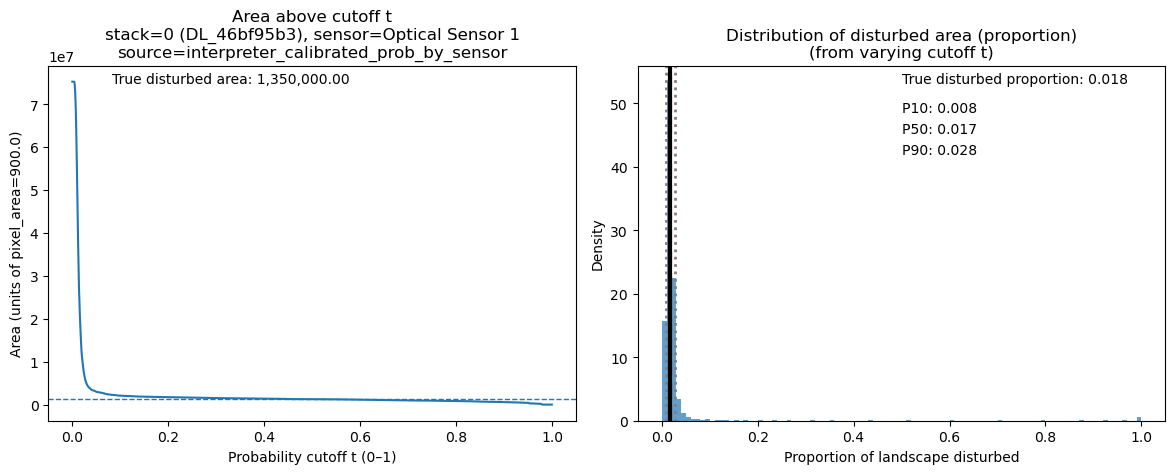

10th, 50th, and 90th percentile DISTURBED PROPORTIONS: 0.007820, 0.016612, 0.027644
True disturbed proportion: 0.017939


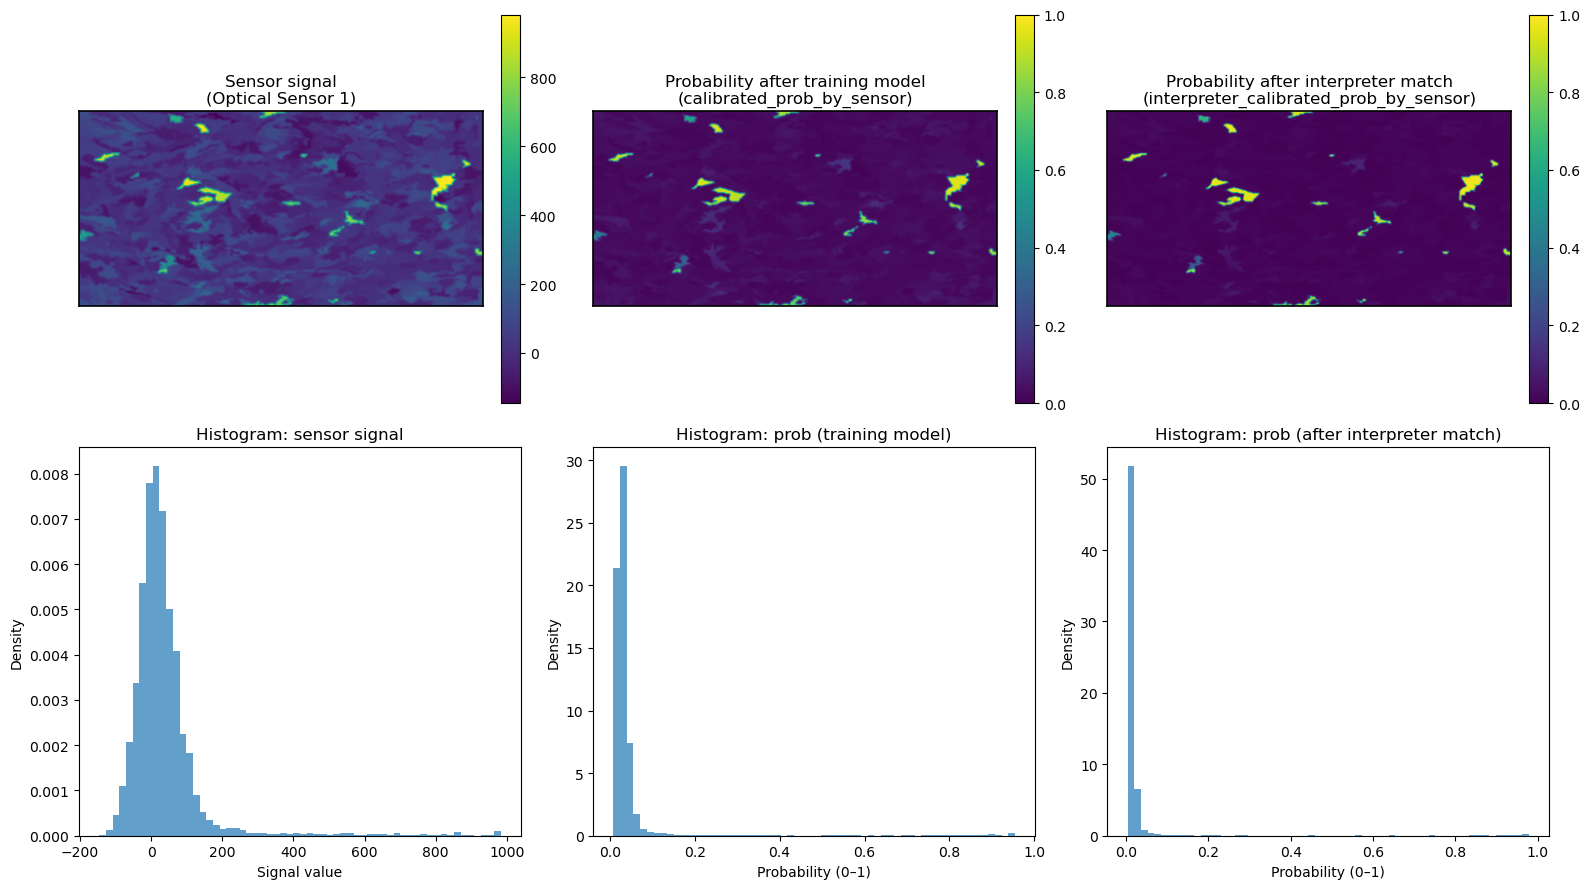


================ AREA PROPORTION SUMMARY (Probability-based) ================
Stack: 0 (DL_46bf95b3)   Sensor: Optical Sensor 1   Source: interpreter_calibrated_prob_by_sensor
Total pixels: 83,616   pixel_area: 900.0   total_area: 75,254,400.000

Estimated disturbed proportion P(class 1) from cutoff-sweep distribution:
  P5 :  0.005439
  P50:  0.016612   (median)
  P95:  0.039739

Estimated undisturbed proportion P(class 0) = 1 - P(class 1):
  P5 :  0.960261
  P50:  0.983388   (median)
  P95:  0.994561

Truth (from base_landscape.disturbed):
  True disturbed proportion: 0.017939
  Is truth within [P5, P95] of estimated P(class 1)? True


(<Figure size 1200x500 with 2 Axes>, <Figure size 1600x900 with 9 Axes>)

In [8]:
#Continous model:  load and run the trainin gmodel, evaluate

# apply the logistic to the validation collection

# load the model from the training collection (a couple panels up ^ )

val_collection.loadModel(trained_models)

val_collection.applyModel()

val_collection.buildInterpreterProbModel(
        sensor_name= "Optical Sensor 1", 
        n_strata= 5,
        samples_per_stratum=100,
        sampling_seed=11, 
        interpreter_agent=val_interp1
    )

val_collection.applyInterpreterProbModel(
        sensor_name="Optical Sensor 1", 
        store_attr_name="interpreter_calibrated_prob_by_sensor"
    )

val_collection.plot_area_distribution_for_stack(
    stack_index=0,
    sensor_name="Optical Sensor 1",
    prob_source_attr="interpreter_calibrated_prob_by_sensor",
    pixel_area=900.0,
    step=0.001,
    bins=100,
    show_true_area=True,
    show_diagnostics=True,
)



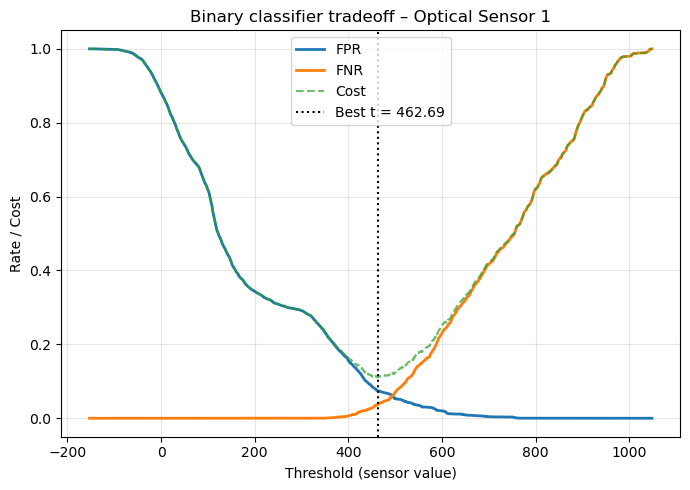

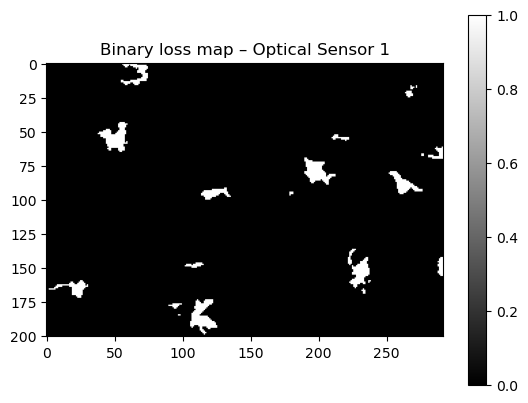

In [9]:
# Binary case:  build model

train_collection.buildBinaryClassifier()   # classic binary loss
# Visualize tradeoff curves
train_collection.plotBinaryCurves("Optical Sensor 1")

# Apply the classifier to all stacks
train_collection.applyBinaryClassifier()

# Look at a binary loss map for one stack/sensor
stack0 = train_collection.stacks[0]
bin_map = stack0.binary_class_by_sensor["Optical Sensor 1"]

import matplotlib.pyplot as plt
plt.imshow(bin_map, cmap="gray")
plt.title("Binary loss map – Optical Sensor 1")
plt.colorbar()
plt.show()




In [10]:
# next build a validation dataset from a different set of landscapes
#  to do this, we need to make sure that the landscapes are different.  

# used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

# val_experiment_config = {
#     "n_stacks": 1,   # or however many you want for this second set
#  #   "disturbance_seed_base": 20_000,
#   #  "use_separate_seeds_per_stack": True,

#     "patch_dir": "downloaded_images/",
#    # "patch_selection_seed": 456,  # different seed from training if you want

#     "sensor_name_for_strat": "Optical Sensor 1",
#     "n_strata": 5,
#     "samples_per_stratum": 200,
# #    "sampling_seed": 99,
# }

# val_collection = LandscapeStackCollection.from_config(
#     stack_template_cfg=landscape_stack_config,
#     experiment_cfg=val_experiment_config,
#     exclude_tif_paths=used_tifs,
# )



In [11]:
#  Now apply the models from the training set, and apply the classifier. 
#  then sample and validate

# 1. Load binary models from training and apply to val_collection
val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier()

# 2. Draw stratified sample from binary map
samples = val_collection.binary_stratified_sample(
    sensor_name="Optical Sensor 1",              # or your sensor name
    n_samples_per_class={0: 100, 1: 100},   # configure as you wish
    sampling_seed=123,
    include_truth=True,
    interpreter_agent = val_interp1,   # this was defined in an earlier block along with the expert one. 
)

print(samples.head())
print(len(samples), "samples total")

# 3. Quick confusion matrix check
cm = val_collection.binary_confusion_from_samples(samples)
print("n_ij:")
print(cm["n_ij"])
print("n_i:", cm["n_i"], "n_total:", cm["n_total"])
n_ij = cm["n_ij"]

n00, n01 = n_ij[0, 0], n_ij[0, 1]
n10, n11 = n_ij[1, 0], n_ij[1, 1]

TN = n00  # map=0, ref=0
FP = n10  # map=1, ref=0
FN = n01  # map=0, ref=1
TP = n11  # map=1, ref=1

print("\n================ CONFUSION MATRIX (Reference vs Classified) ================\n")
print("                Predicted")
print("              |   0     |    1   ")
print("        --------------------------")
print(f"Reference 0  |  {n00:5d} | {n01:5d}")
print(f"Reference 1  |  {n10:5d} | {n11:5d}")
print("\nInterpretation:")
print(f"  True Negatives (TN): {TN} -- correctly predicted no-loss")
print(f"  False Positives (FP): {FP} -- predicted disturbance where interpreter said none")
print(f"  False Negatives (FN): {FN} -- missed disturbance according to interpreter")
print(f"  True Positives (TP): {TP} -- correctly predicted disturbance\n")

print("Derived metrics:")
total = n00 + n01 + n10 + n11
acc = (TP + TN) / total if total > 0 else float('nan')
sens = TP / (TP + FN) if (TP + FN) > 0 else float('nan')   # recall
spec = TN / (TN + FP) if (TN + FP) > 0 else float('nan')   # specificity
ppv = TP / (TP + FP) if (TP + FP) > 0 else float('nan')    # precision
npv = TN / (TN + FN) if (TN + FN) > 0 else float('nan')

print(f"  Overall Accuracy:     {acc:0.3f}")
print(f"  Sensitivity (TPR):    {sens:0.3f}  (recall)")
print(f"  Specificity (TNR):    {spec:0.3f}")
print(f"  Precision (PPV):      {ppv:0.3f}")
print(f"  Neg. Predictive Val.: {npv:0.3f}")
print("==========================================================================\n")

# 4. Olofsson error-adjusted area estimates
ol = val_collection.olofsson_area_estimates(
    samples,
    sensor_name="Optical Sensor 1",
    disturbed_class=1,
    alpha=0.05,
)

print(f"Map area proportions W (map class 0,1): {ol["W"][0]:0.3f},{ol["W"][1]:0.3f} ")
print(f"Adjusted area proportions P̂ (ref class 0,1): {ol["P_hat"][0]:0.3f},{ol["P_hat"][1]:0.3f}")
print(f"SE(P̂): {ol["SE"]}.03.f")
print("95% CI (class 0,1):")
print(f"Map class 0: lower and upper: {ol["CI"]["lower"][0]:0.3f}, {ol["CI"]["upper"][0]:0.3f}")
print(f"Map class 1: lower and upper: {ol["CI"]["lower"][1]:0.3f}, {ol["CI"]["upper"][1]:0.3f}")

# print(f"SE(P̂): {ol["SE"]:0.3f}")
# print("95% CI (class 0,1):")
# print(f"  lower: {ol["CI"]["lower"]:0.3f}")
# print(f"  upper: {ol["CI"]["upper"]:0.3f}")

print(f"True disturbed proportion: {ol["true_disturbed_prop"]:0.3f}")
print("Is true disturbed within CI for class 1?", ol["disturbed_in_CI"])

# visualization stuff
val_collection.debug_plot_truth_vs_binary(
    stack_index=0,
    sensor_name="Optical Sensor 1",
    samples=samples,
)


SyntaxError: f-string: unmatched '[' (2780711420.py, line 70)

In [ ]:




experiment_config = {
    "landscape_stack_config":  landscape_stack_config, 
    "training_experiment_config": train_experiment_config,
    "training_interp_config": model_building_interp_cfg, 
    "validation_experiment_config": val_experiment_config, 
    "validation_interp_config": validation_interp1_cfg
}


export_with_metadata(experiment_config, notes="first full run with no noise")

